# Solutions

:::{admonition} Reference solutions
:class: note
Worked solutions for the seven exercises in [04-matplotlib-and-xarray-exercises.ipynb](04-matplotlib-and-xarray-exercises.ipynb).
:::

## Exercise 1: A labelled line plot

Given `days = np.arange(365)` and `temp_celsius = 10 + 8 * np.sin(2 * np.pi * days / 365)`, plot temperature against day of year as a line, with axis labels (including the unit) and a title.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

days = np.arange(365)
temp_celsius = 10 + 8 * np.sin(2 * np.pi * days / 365)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(days, temp_celsius, color="tab:red")
ax.set_xlabel("day of year")
ax.set_ylabel("temperature (°C)")
ax.set_title("synthetic annual cycle")
plt.show()

## Exercise 2: Scatter and histogram side by side

With `rng = np.random.default_rng(0)`, `x = np.arange(100)`, and `y = 0.1 * x + rng.normal(0, 1, 100)`, make a 1×2 figure: a scatter of `y` versus `x` on the left, and a histogram of `y` on the right. Label all axes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
x = np.arange(100)
y = 0.1 * x + rng.normal(0, 1, 100)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

axes[0].scatter(x, y, s=10, color="tab:blue")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("scatter")

axes[1].hist(y, bins=20, color="tab:gray")
axes[1].set_xlabel("y")
axes[1].set_ylabel("count")
axes[1].set_title("distribution")

plt.tight_layout()
plt.show()

## Exercise 3: A 2D field with a colorbar, saved as vector

Given

```python
lon = np.linspace(6.0, 9.0, 6)
lat = np.linspace(46.0, 47.5, 4)
field_celsius = np.random.default_rng(0).normal(5, 2, size=(4, 6))
```

draw the field with `pcolormesh` and the coordinates, add a labelled colorbar and axis labels, and save the figure as `field.svg`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lon = np.linspace(6.0, 9.0, 6)
lat = np.linspace(46.0, 47.5, 4)
field_celsius = np.random.default_rng(0).normal(5, 2, size=(4, 6))

fig, ax = plt.subplots(figsize=(5, 3))
pcm = ax.pcolormesh(lon, lat, field_celsius, shading="auto")
fig.colorbar(pcm, ax=ax, label="temperature (°C)")
ax.set_xlabel("longitude (°E)")
ax.set_ylabel("latitude (°N)")
fig.savefig("field.svg")
plt.show()

## Exercise 4: Build a labelled DataArray

From `data = np.arange(12.0).reshape(3, 4)`, build an xarray DataArray with dimensions `("lat", "lon")`, latitude coordinates `[46.0, 46.5, 47.0]`, longitude coordinates `[6.0, 6.5, 7.0, 7.5]`, and a `units` attribute of `"degC"`. Print its dims and its units.

In [ ]:
import numpy as np
import xarray as xr

data = np.arange(12.0).reshape(3, 4)
da = xr.DataArray(
    data,
    dims=("lat", "lon"),
    coords={"lat": [46.0, 46.5, 47.0], "lon": [6.0, 6.5, 7.0, 7.5]},
    attrs={"units": "degC"},
)
print(da.dims)
print(da.attrs["units"])

## Exercise 5: Select and reduce

Build the small Dataset below, then print the spatial mean of the first day (by position) and the time mean at latitude 47.0 (by label).

```python
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2024-01-11", dtype="datetime64[D]")
lat = np.array([46.0, 46.5, 47.0]); lon = np.array([6.0, 6.5, 7.0, 7.5])
t = rng.normal(5, 3, size=(10, 3, 4))
ds = xr.Dataset({"t2m": (("time", "lat", "lon"), t)},
                coords={"time": time, "lat": lat, "lon": lon})
```

In [ ]:
import numpy as np
import xarray as xr

rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2024-01-11", dtype="datetime64[D]")
lat = np.array([46.0, 46.5, 47.0]); lon = np.array([6.0, 6.5, 7.0, 7.5])
t = rng.normal(5, 3, size=(10, 3, 4))
ds = xr.Dataset({"t2m": (("time", "lat", "lon"), t)},
                coords={"time": time, "lat": lat, "lon": lon})

print("first day spatial mean:", ds["t2m"].isel(time=0).mean().item())
print("time mean at lat=47.0:", ds["t2m"].sel(lat=47.0).mean(dim="time").values)

## Exercise 6: Resample and a monthly climatology

Build a one-year daily temperature DataArray (construction below), compute its monthly means with `resample`, print how many there are, then use `groupby` to find the warmest calendar month (1–12).

```python
rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2025-01-01", dtype="datetime64[D]")
n = time.size; doy = np.arange(n)
t = 5 + -np.cos(2 * np.pi * doy / n) * 10 + rng.normal(0, 1.5, n)
da = xr.DataArray(t, dims="time", coords={"time": time}, attrs={"units": "degC"})
```

In [ ]:
import numpy as np
import xarray as xr

rng = np.random.default_rng(0)
time = np.arange("2024-01-01", "2025-01-01", dtype="datetime64[D]")
n = time.size; doy = np.arange(n)
t = 5 + -np.cos(2 * np.pi * doy / n) * 10 + rng.normal(0, 1.5, n)
da = xr.DataArray(t, dims="time", coords={"time": time}, attrs={"units": "degC"})

monthly = da.resample(time="MS").mean()
print("monthly steps:", monthly["time"].size)

clim_by_month = da.groupby("time.month").mean()
warmest_month = int(clim_by_month.argmax("month").item()) + 1
print("warmest month:", warmest_month)

## Exercise 7: Round-trip through netCDF

Create a 1D temperature DataArray named `t2m` with a `units` attribute, write it to `series.nc`, reopen it with `open_dataset`, and print the variable names and the recovered units.

In [ ]:
import numpy as np
import xarray as xr

t2m = xr.DataArray(
    np.arange(5.0),
    dims="time",
    coords={"time": np.arange("2024-01-01", "2024-01-06", dtype="datetime64[D]")},
    name="t2m",
    attrs={"units": "degC"},
)
t2m.to_dataset().to_netcdf("series.nc")

reopened = xr.open_dataset("series.nc")
print(list(reopened.data_vars))
print(reopened["t2m"].attrs["units"])
reopened.close()

## Exercise 8: A field on a map with cartopy

Rebuild the DataArray `da` from exercise 4. Plot it on a `ccrs.PlateCarree()` projection with `.coastlines()` and a labelled colorbar, using `transform=ccrs.PlateCarree()`.

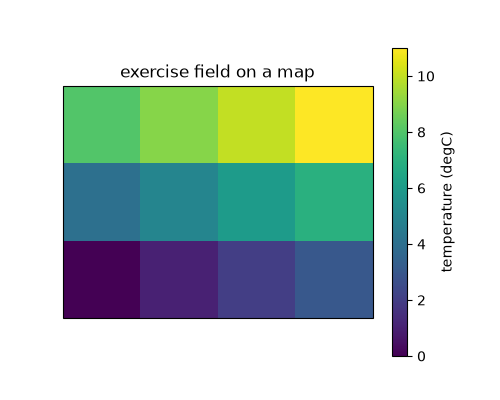

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

data = np.arange(12.0).reshape(3, 4)
da = xr.DataArray(
    data,
    dims=("lat", "lon"),
    coords={"lat": [46.0, 46.5, 47.0], "lon": [6.0, 6.5, 7.0, 7.5]},
    attrs={"units": "degC"},
)

fig, ax = plt.subplots(figsize=(5, 4), subplot_kw={"projection": ccrs.PlateCarree()})
da.plot(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={"label": "temperature (degC)"})
ax.coastlines()
ax.set_title("exercise field on a map")
plt.show()